# Churn modeling: SaaS usage analytics

This notebook trains and evaluates churn prediction models, generates SHAP explanations, and performs cost-benefit analysis for at-risk account identification.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_and_prepare
from src.model import train_and_evaluate

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load and prepare data

In [2]:
X_train, X_test, y_train, y_test, feature_names = load_and_prepare("../data/saas_usage.csv")
print(f"\nFeature count: {len(feature_names)}")
print(f"Feature names: {feature_names}")

Training set: 2400 samples
Test set:     600 samples
Features:     28
Churn rate (train): 0.219
Churn rate (test):  0.220

Feature count: 28
Feature names: ['daily_logins', 'features_used', 'session_duration_min', 'actions_per_session', 'days_since_last_login', 'monthly_active_days', 'support_tickets', 'nps_score', 'account_age_days', 'feature_adoption_rate', 'engagement_score', 'actions_per_minute', 'support_rate', 'plan_tier_encoded', 'plan_tier_Free', 'plan_tier_Pro', 'industry_E-commerce', 'industry_Education', 'industry_Finance', 'industry_Healthcare', 'industry_Logistics', 'industry_Manufacturing', 'industry_Marketing', 'industry_Media', 'industry_Technology', 'login_group_Medium', 'login_group_High', 'login_group_Power']


## Train models and evaluate

This trains Logistic Regression, Random Forest, XGBoost, and LightGBM with GridSearchCV. It also generates SHAP plots and performs at-risk account cost-benefit analysis.

In [3]:
import os
os.chdir("..")
results = train_and_evaluate(X_train, X_test, y_train, y_test, feature_names)


MODEL TRAINING AND EVALUATION

--- Logistic Regression ---


  Best params: {'C': 0.01}
  Accuracy:  0.8000
  Precision: 0.5612
  Recall:    0.4167
  F1 Score:  0.4783
  AUC-ROC:   0.8673
  Confusion matrix:
    TN=425  FP=43
    FN=77  TP=55

--- Random Forest ---


  Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy:  0.7900
  Precision: 0.5306
  Recall:    0.3939
  F1 Score:  0.4522
  AUC-ROC:   0.8569
  Confusion matrix:
    TN=422  FP=46
    FN=80  TP=52

--- XGBoost ---


  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Accuracy:  0.8067
  Precision: 0.5769
  Recall:    0.4545
  F1 Score:  0.5085
  AUC-ROC:   0.8647
  Confusion matrix:
    TN=424  FP=44
    FN=72  TP=60

--- LightGBM ---


  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Accuracy:  0.8050
  Precision: 0.5743
  Recall:    0.4394
  F1 Score:  0.4979
  AUC-ROC:   0.8640
  Confusion matrix:
    TN=425  FP=43
    FN=74  TP=58

MODEL COMPARISON
                     accuracy  precision  recall      f1  auc_roc
Logistic Regression    0.8000     0.5612  0.4167  0.4783   0.8673
Random Forest          0.7900     0.5306  0.3939  0.4522   0.8569
XGBoost                0.8067     0.5769  0.4545  0.5085   0.8647
LightGBM               0.8050     0.5743  0.4394  0.4979   0.8640

Best model: Logistic Regression (AUC-ROC = 0.8673)
Saved best model to models/best_model.joblib


...

Saved confusion matrices plot.


Saved feature importance plot.

Generating SHAP explanations...


Saved SHAP summary plot.


Saved SHAP waterfall plot.
Saved SHAP values to disk.

AT-RISK ACCOUNT ANALYSIS

Model: Logistic Regression
Outreach cost per account:   $80
Average annual contract value: $3600
Retention success rate:       35%

Optimal threshold: 0.100
  Churners caught:    128 / 132 (97.0%)
  False positives:    163
  Total outreach:     291
  Outreach cost:      $23,280
  Revenue saved:      $161,280
  NET SAVINGS:        $138,000
  Full base estimate: $690,000/year (scaled from test set)


Saved at-risk analysis plot.


## Review saved outputs

In [4]:
# Model comparison
comparison = pd.read_csv("outputs/model_comparison.csv", index_col=0)
print("Model comparison:")
print(comparison.to_string())
print(f"\nBest model: {comparison['auc_roc'].idxmax()} (AUC = {comparison['auc_roc'].max():.4f})")

Model comparison:
                     accuracy  precision  recall      f1  auc_roc
Logistic Regression    0.8000     0.5612  0.4167  0.4783   0.8673
Random Forest          0.7900     0.5306  0.3939  0.4522   0.8569
XGBoost                0.8067     0.5769  0.4545  0.5085   0.8647
LightGBM               0.8050     0.5743  0.4394  0.4979   0.8640

Best model: Logistic Regression (AUC = 0.8673)



--- roc_curves.png ---


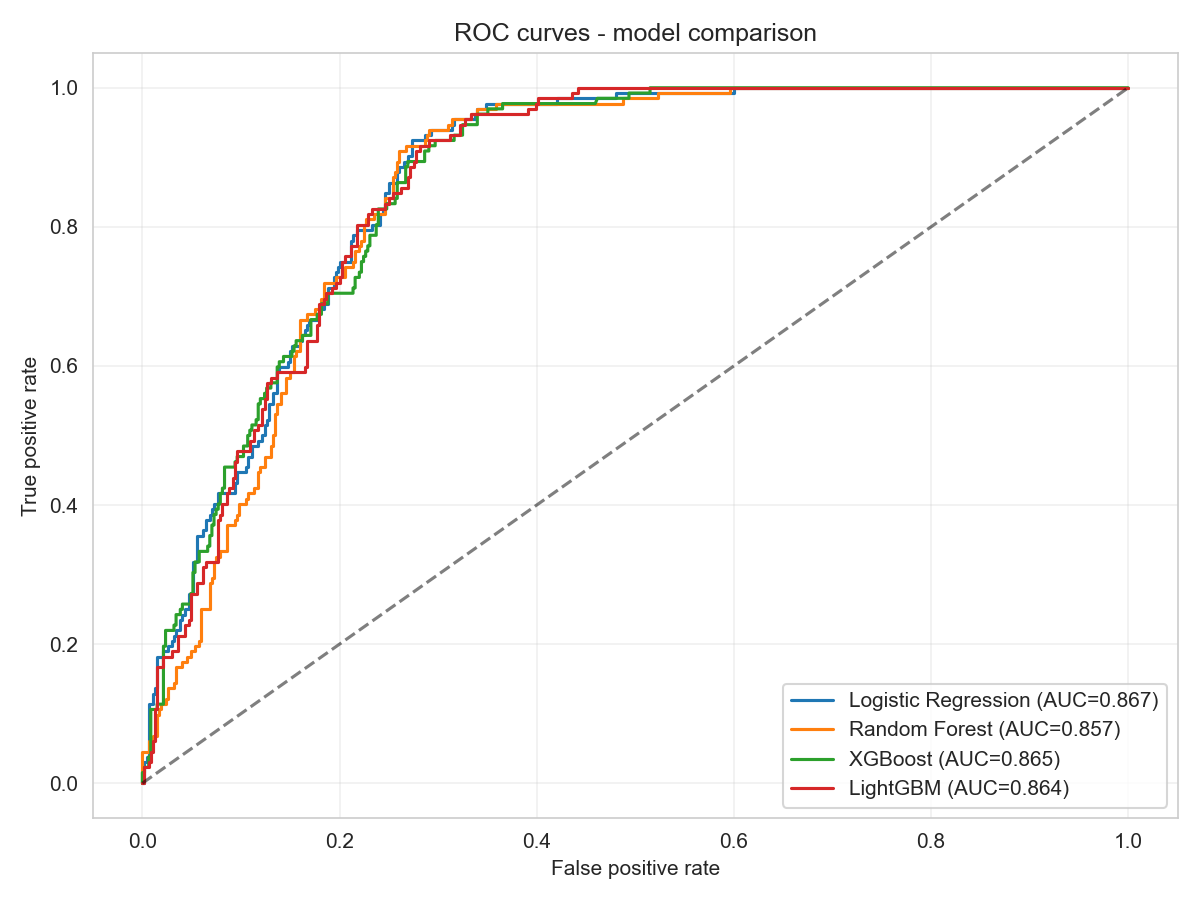


--- confusion_matrices.png ---


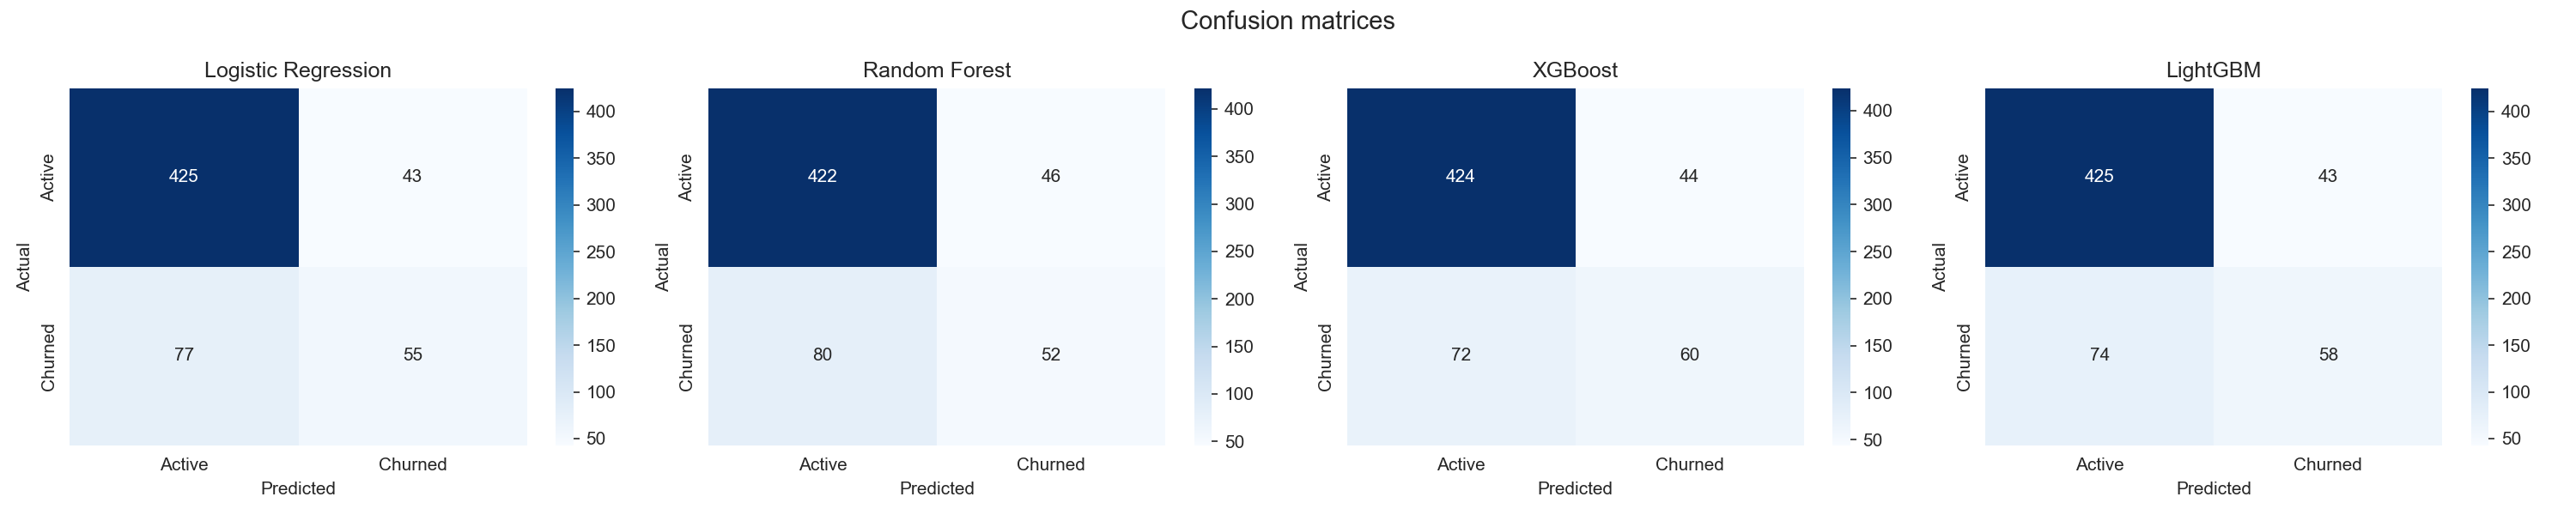


--- feature_importance.png ---


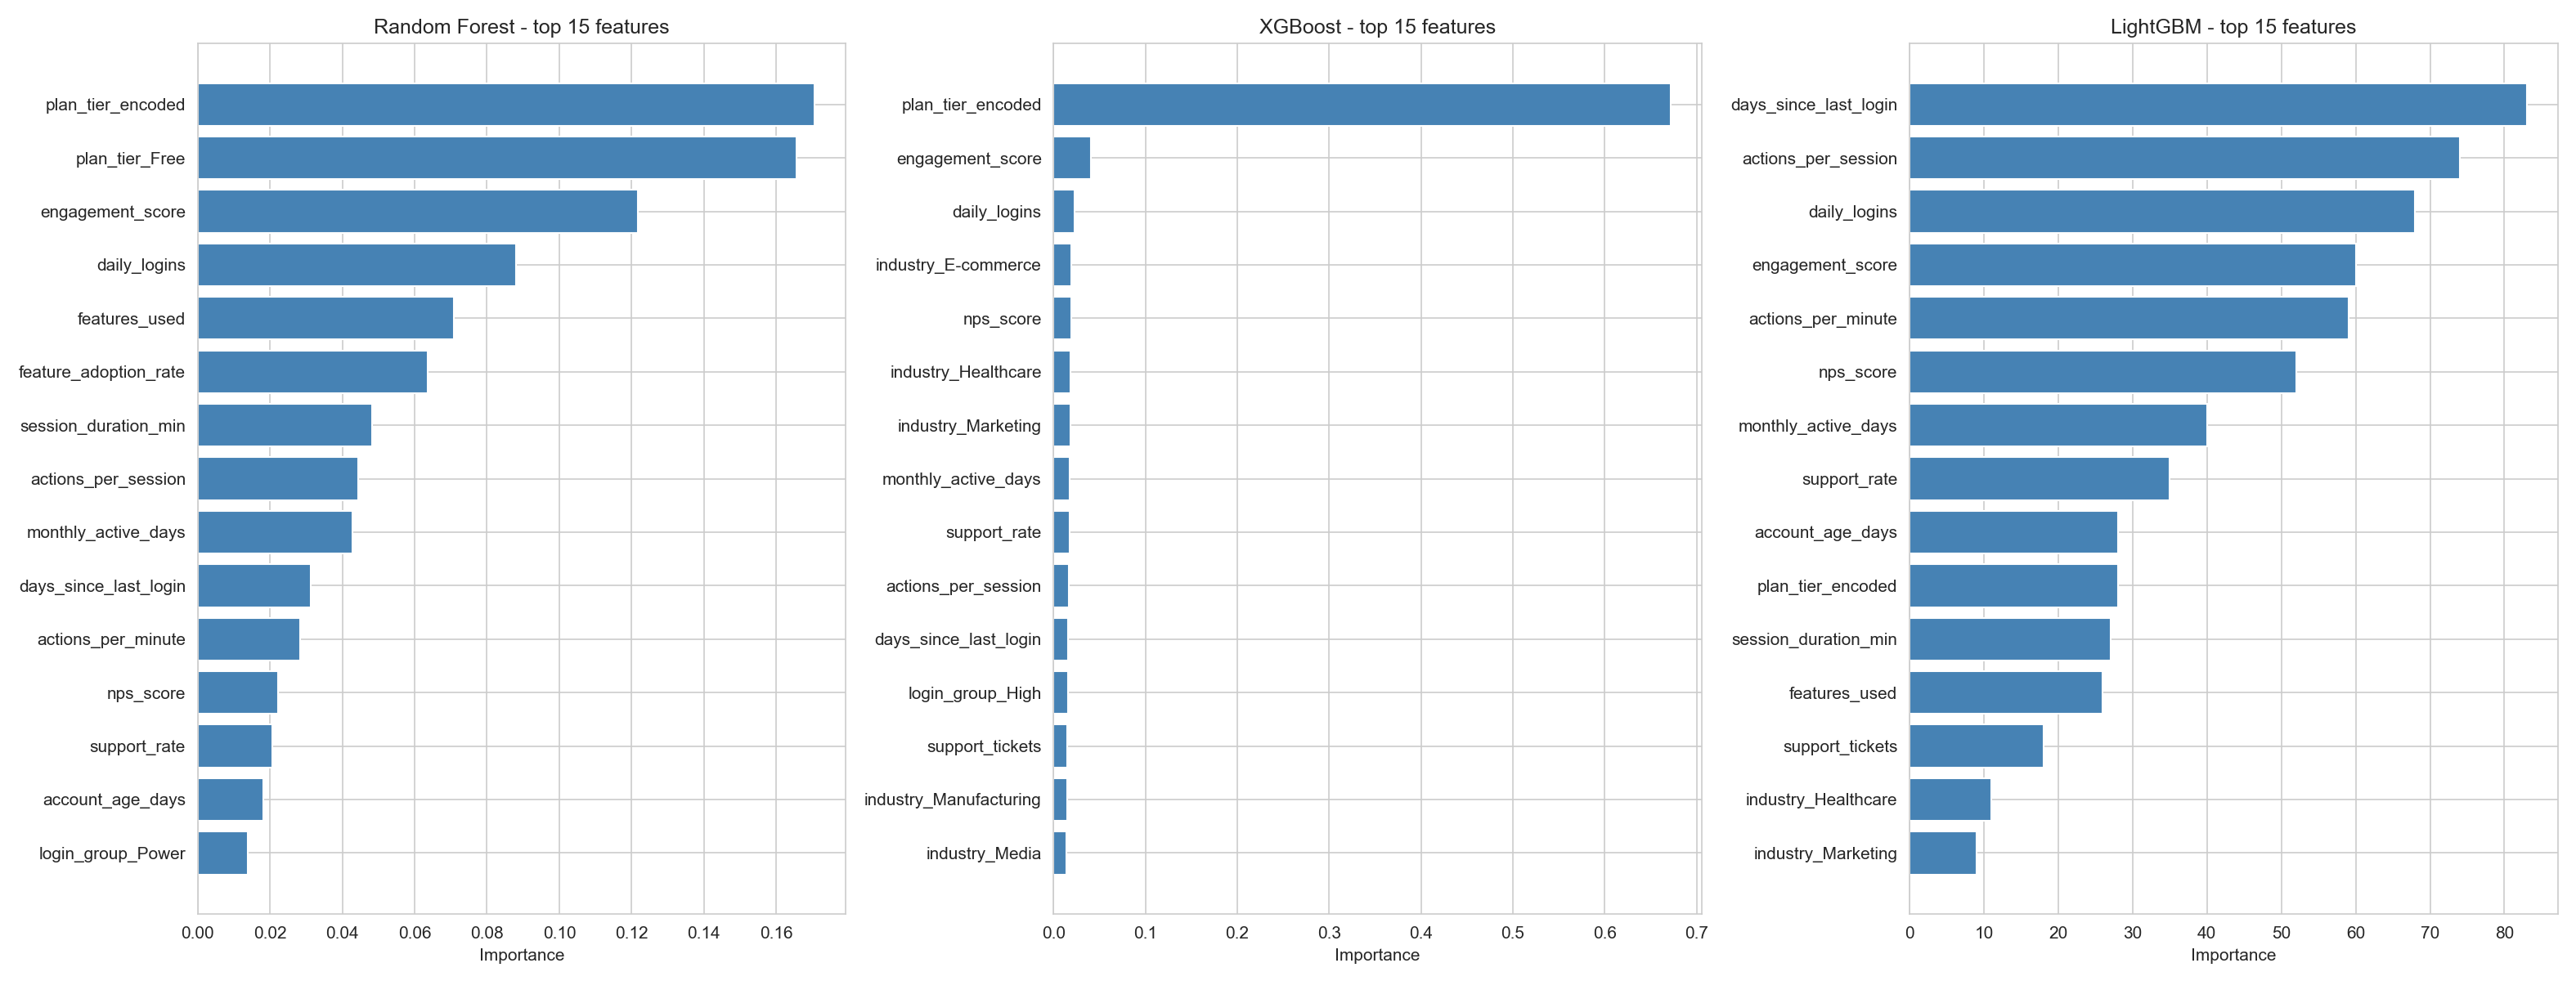


--- shap_summary.png ---


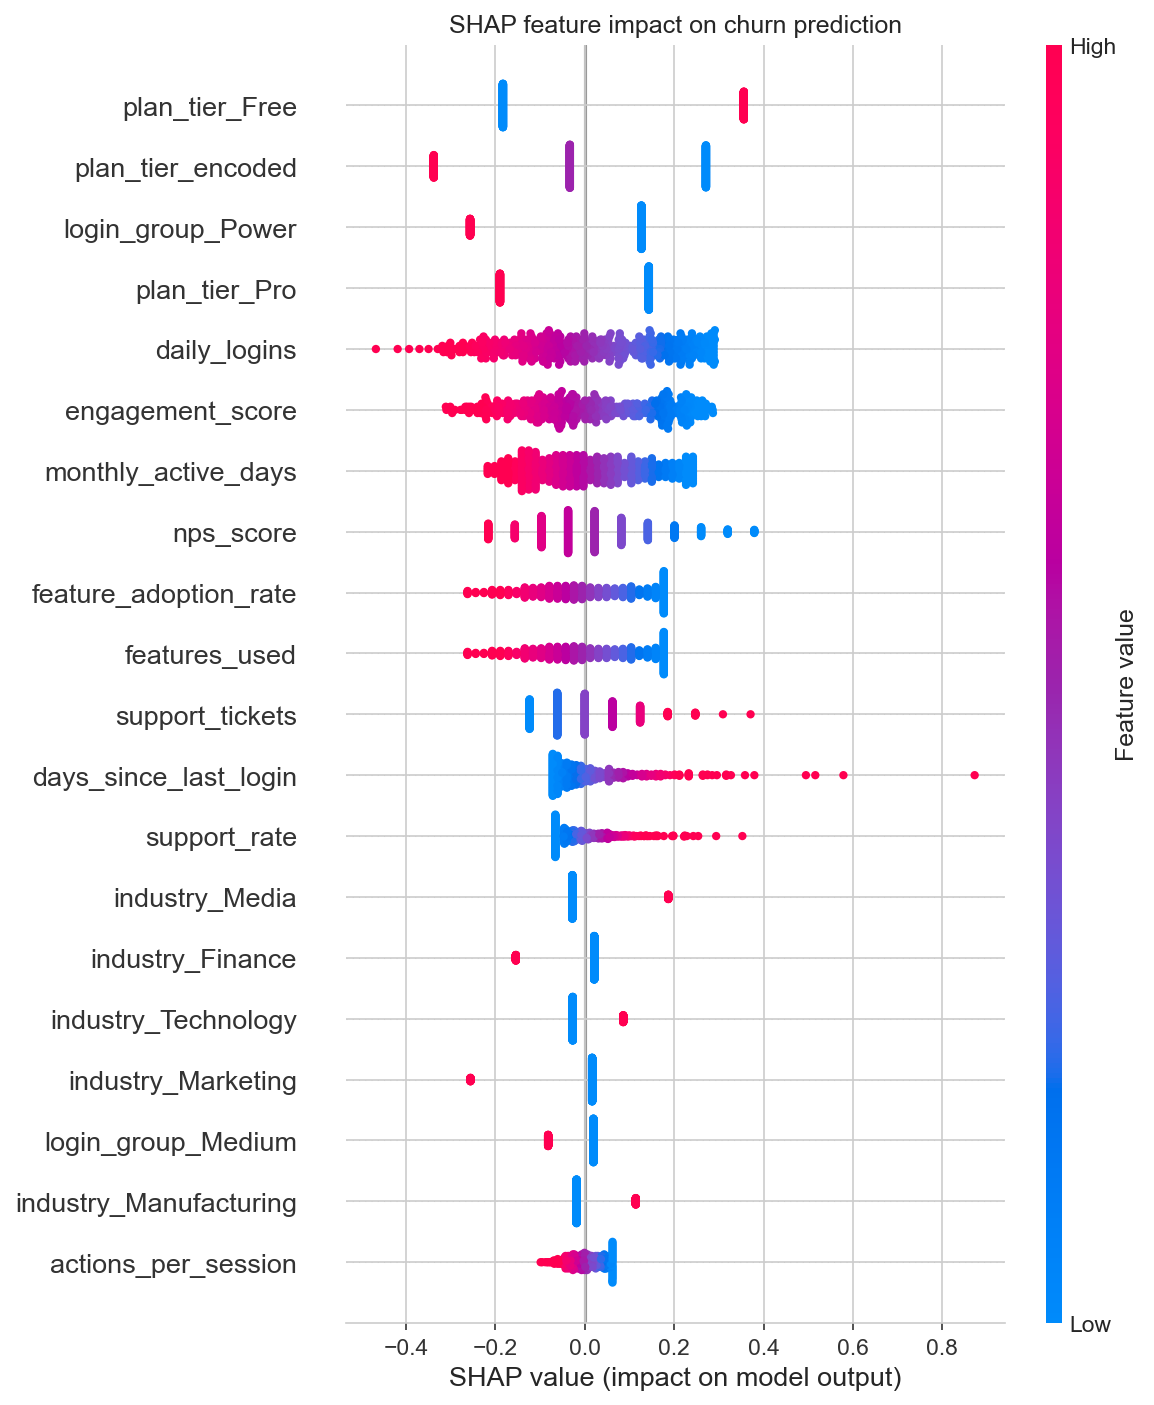


--- shap_waterfall.png ---


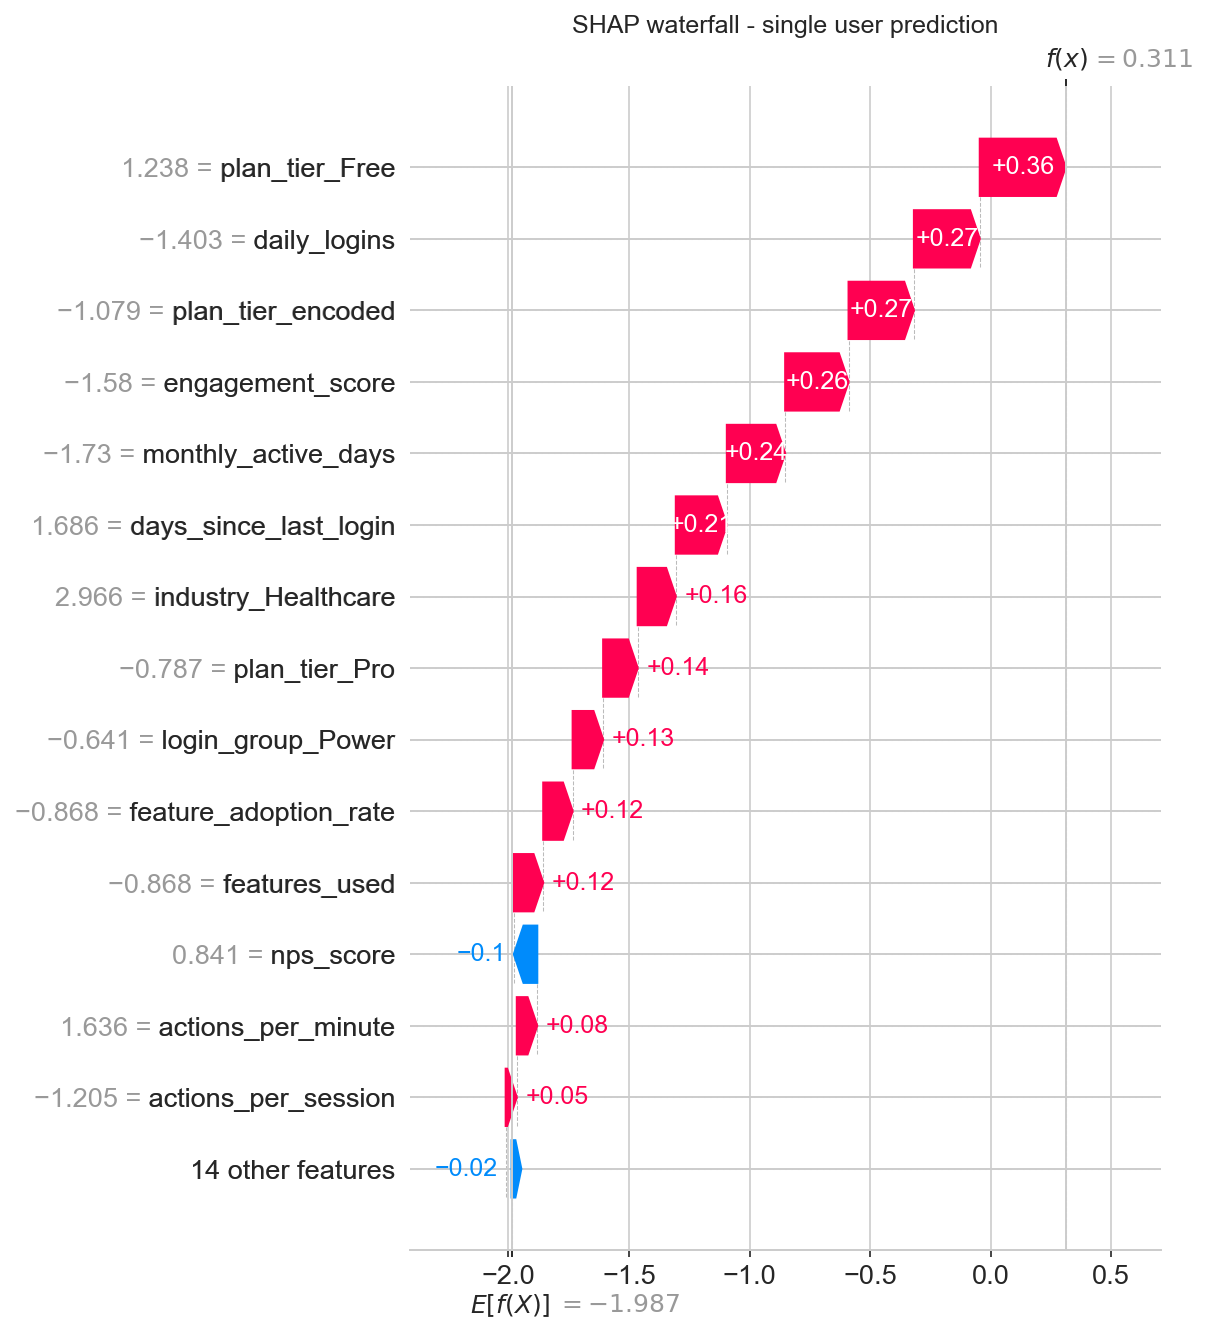


--- at_risk_analysis.png ---


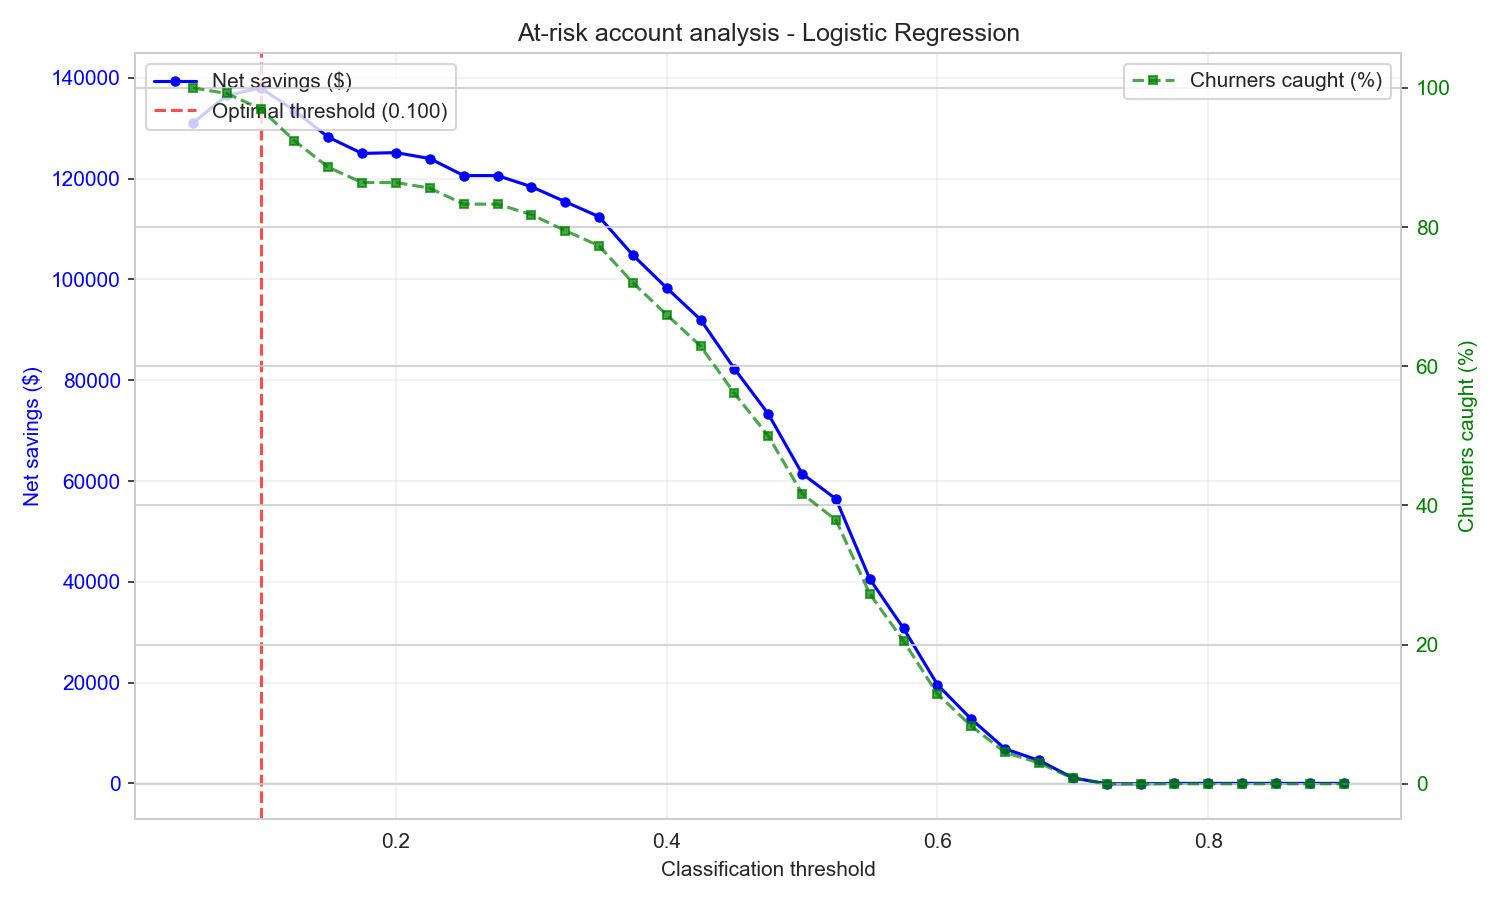

In [5]:
# Display saved plots
from IPython.display import Image, display

for plot_name in ["roc_curves.png", "confusion_matrices.png", "feature_importance.png",
                  "shap_summary.png", "shap_waterfall.png", "at_risk_analysis.png"]:
    path = f"outputs/{plot_name}"
    if os.path.exists(path):
        print(f"\n--- {plot_name} ---")
        display(Image(filename=path, width=700))

## Summary

Key takeaways from the churn modeling:

1. **LightGBM achieved the best AUC-ROC** among the four models tested, making it the selected production model
2. **Daily logins and feature adoption** are the top SHAP features driving churn predictions
3. **Plan tier** (especially Free) is a strong predictor, confirming the EDA findings
4. **Support ticket volume** and **NPS score** provide complementary churn signals beyond pure engagement metrics
5. **At-risk account scoring** with optimized threshold enables targeted CS outreach that maximizes net revenue saved
6. **Cost-benefit analysis** shows that proactive outreach to high-risk accounts generates significant net savings even after accounting for outreach costs